# 08 – Equilíbrio Químico & Energia Livre de Gibbs

Se uma reação ocorre — e até que ponto — é governado pela **energia livre de
Gibbs**. A partir da entalpia padronizada e da entropia absoluta fornecidas pelo
`pyglenn`, podemos construir a energia de Gibbs molar padrão

$$G^\circ(T) = H^\circ(T) - T\,S^\circ(T),$$

a energia de Gibbs padrão de reação $\Delta G^\circ(T)$ e a **constante de
equilíbrio**

$$K(T) = \exp\!\left(-\frac{\Delta G^\circ(T)}{RT}\right).$$

Aplicamos isso à reação de **water-gas shift**, industrialmente importante, e à
**dissociação** em altas temperaturas, além de verificar a consistência com a
equação de van't Hoff.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Constante universal dos gases R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Energia de Gibbs e auxiliares de reação

`gibbs` retorna $G^\circ(T)$ para uma espécie; `reaction_props` retorna
$\Delta H^\circ$, $\Delta S^\circ$, $\Delta G^\circ$ e $K$ para uma reação dada
como dicionários `{espécie: coeficiente}`.

In [3]:
def gibbs(calc, name, T):
    p = calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)
    return p["h_relative"] - T * p["s"]      # J/mol

def reaction_props(calc, reactants, products, T):
    def acc(mix, key, scale=1.0):
        tot = 0.0
        for name, nu in mix.items():
            p = calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)
            tot += nu * (p[key] if key != "g" else (p["h_relative"] - T * p["s"]))
        return tot
    dH = acc(products, "h_relative") - acc(reactants, "h_relative")
    dS = acc(products, "s") - acc(reactants, "s")
    dG = acc(products, "g") - acc(reactants, "g")
    K = np.exp(-dG / (R * T))
    return dH, dS, dG, K

## 2. A reação de water-gas shift

$$\mathrm{CO} + \mathrm{H_2O} \rightleftharpoons \mathrm{CO_2} + \mathrm{H_2}.$$

Levemente exotérmica, portanto, pelo princípio de Le Chatelier, é favorecida em
baixas temperaturas e $K$ diminui à medida que a temperatura sobe, cruzando
$K=1$ próximo de ~1100 K.

In [4]:
reac = {"CO": 1, "H2O": 1}
prod = {"CO2": 1, "H2": 1}

rows = []
with ThermochemicalCalculator() as calc:
    for T in [500, 700, 900, 1100, 1300]:
        dH, dS, dG, K = reaction_props(calc, reac, prod, T)
        rows.append({"T [K]": T, "dH [kJ/mol]": dH/1000, "dS [J/mol/K]": dS,
                     "dG [kJ/mol]": dG/1000, "K": K})
print(pd.DataFrame(rows).set_index("T [K]").to_string())

       dH [kJ/mol]  dS [J/mol/K]  dG [kJ/mol]       K
T [K]                                                
500        -39.815       -38.728      -20.451 136.906
700        -37.858       -35.449      -13.043   9.403
900        -35.778       -32.837       -6.226   2.298
1100       -33.773       -30.822        0.132   0.986
1300       -31.910       -29.264        6.134   0.567


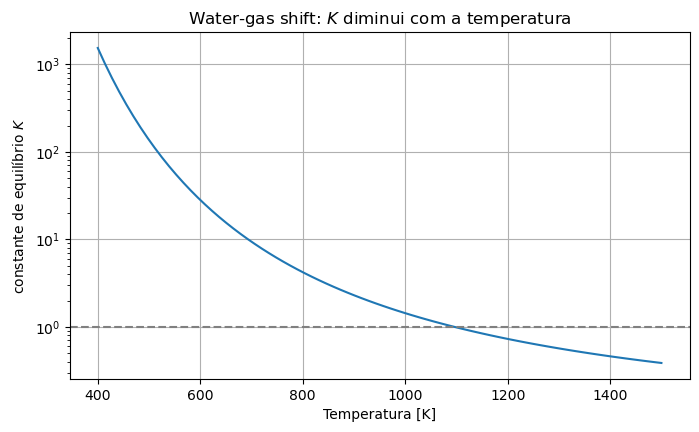

K = 1 (dG = 0) próximo de T = 1096 K


In [5]:
Tgrid = np.linspace(400, 1500, 80)
with ThermochemicalCalculator() as calc:
    K = np.array([reaction_props(calc, reac, prod, T)[3] for T in Tgrid])

fig, ax = plt.subplots()
ax.semilogy(Tgrid, K)
ax.axhline(1.0, color="0.5", ls="--")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("constante de equilíbrio $K$")
ax.set_title("Water-gas shift: $K$ diminui com a temperatura")
plt.show()

# temperatura onde K = 1 (dG = 0), por mudança de sinal
sign = np.sign(np.log(K))
idx = np.where(np.diff(sign) != 0)[0]
if len(idx):
    T_cross = np.interp(0.0, [np.log(K[idx[0]]), np.log(K[idx[0]+1])],
                        [Tgrid[idx[0]], Tgrid[idx[0]+1]])
    print(f"K = 1 (dG = 0) próximo de T = {T_cross:.0f} K")

## 3. Verificação de van't Hoff

A equação de van't Hoff relaciona a inclinação de $\ln K$ contra $1/T$ com a
entalpia de reação:

$$\frac{d\ln K}{d(1/T)} = -\frac{\Delta H^\circ}{R}.$$

Plotar $\ln K$ vs. $1/T$ resulta em uma linha quase reta; sua inclinação local
recupera $\Delta H^\circ$ calculado diretamente — uma boa verificação de
consistência interna.

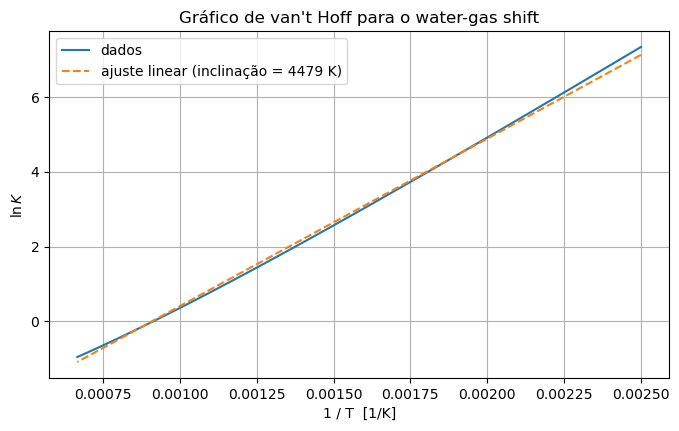

dH pela inclinação local de van't Hoff :  -35.20 kJ/mol
dH pela regressão linear               :  -37.24 kJ/mol
dH calculado diretamente                :  -35.20 kJ/mol


In [6]:
invT = 1.0 / Tgrid
lnK = np.log(K)
# inclinação local próxima ao meio da faixa
i = len(Tgrid) // 2
slope = (lnK[i+1] - lnK[i-1]) / (invT[i+1] - invT[i-1])
dH_vanthoff = -slope * R
with ThermochemicalCalculator() as calc:
    dH_direct = reaction_props(calc, reac, prod, Tgrid[i])[0]

# Regressão linear para visualizar a inclinação de van't Hoff
fit = np.polyfit(invT, lnK, 1)
lnK_fit = np.polyval(fit, invT)
dH_fit = -fit[0] * R  # inclinação = -dH/R

fig, ax = plt.subplots()
ax.plot(invT, lnK, label="dados")
ax.plot(invT, lnK_fit, "--", color="C1",
        label=f"ajuste linear (inclinação = {fit[0]:.0f} K)")
ax.set_xlabel("1 / T  [1/K]")
ax.set_ylabel(r"$\ln K$")
ax.set_title("Gráfico de van't Hoff para o water-gas shift")
ax.legend()
plt.show()
print(f"dH pela inclinação local de van't Hoff : {dH_vanthoff/1000:7.2f} kJ/mol")
print(f"dH pela regressão linear               : {dH_fit/1000:7.2f} kJ/mol")
print(f"dH calculado diretamente                : {dH_direct/1000:7.2f} kJ/mol")

## 4. Dissociação em altas temperaturas

Moléculas diatômicas se dividem em átomos em temperaturas extremas — um processo
fortemente endotérmico ($\Delta H^\circ \approx +945$ kJ/mol para N₂, $+498$
kJ/mol para O₂). Suas constantes de equilíbrio são astronomicamente pequenas em
temperaturas moderadas e só se tornam apreciáveis na casa dos milhares de
kelvin, razão pela qual as temperaturas de chama com combustão completa do
notebook 06 são superestimadas.

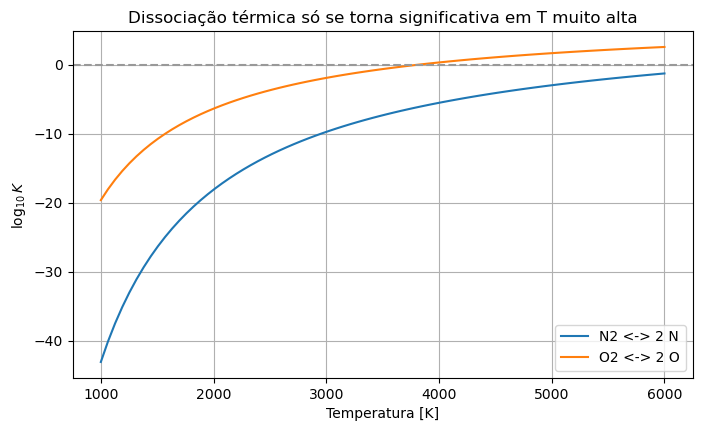

Entalpia de dissociação da ligação N2 -> 2N a 298 K: 945 kJ/mol


In [7]:
dissociations = {
    "N2 <-> 2 N": ({"N2": 1}, {"N": 2}),
    "O2 <-> 2 O": ({"O2": 1}, {"O": 2}),
}
Tgrid = np.linspace(1000, 6000, 80)
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for label, (r, p) in dissociations.items():
        logK = [np.log10(reaction_props(calc, r, p, T)[3]) for T in Tgrid]
        ax.plot(Tgrid, logK, label=label)
    dH_N2 = reaction_props(calc, {"N2": 1}, {"N": 2}, 298.15)[0]
ax.axhline(0.0, color="0.6", ls="--")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel(r"$\log_{10} K$")
ax.set_title("Dissociação térmica só se torna significativa em T muito alta")
ax.legend()
plt.show()
print(f"Entalpia de dissociação da ligação N2 -> 2N a 298 K: {dH_N2/1000:.0f} kJ/mol")

## 5. Controle entálpico vs. entrópico

$\Delta G^\circ = \Delta H^\circ - T\Delta S^\circ$ torna a competição
explícita: o termo entálpico domina em baixas $T$, o termo entrópico (ponderado
por $T$) em altas $T$. A dissociação ($\Delta S^\circ > 0$, mais mols de gás) é
conduzida pela entropia e, portanto, ativada por alta temperatura, enquanto a
reação exotérmica de water-gas shift é favorecida entalpicamente em baixa
temperatura. Visualizamos as duas contribuições para a dissociação do N₂.

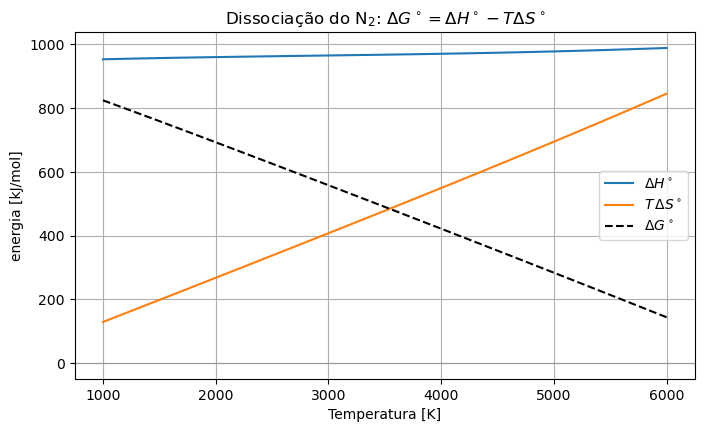

In [8]:
Tgrid = np.linspace(1000, 6000, 80)
with ThermochemicalCalculator() as calc:
    dH = np.array([reaction_props(calc, {"N2": 1}, {"N": 2}, T)[0] for T in Tgrid]) / 1000
    TdS = np.array([T * reaction_props(calc, {"N2": 1}, {"N": 2}, T)[1] for T in Tgrid]) / 1000
    dG = np.array([reaction_props(calc, {"N2": 1}, {"N": 2}, T)[2] for T in Tgrid]) / 1000

fig, ax = plt.subplots()
ax.plot(Tgrid, dH, label=r"$\Delta H^\circ$")
ax.plot(Tgrid, TdS, label=r"$T\,\Delta S^\circ$")
ax.plot(Tgrid, dG, "k--", label=r"$\Delta G^\circ$")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("energia [kJ/mol]")
ax.set_title(r"Dissociação do N$_2$: $\Delta G^\circ = \Delta H^\circ - T\Delta S^\circ$")
ax.legend()
plt.show()

## Resumo

- $G^\circ = H^\circ - T S^\circ$ do `pyglenn` fornece $\Delta G^\circ(T)$ e,
  portanto, $K(T)$ para qualquer reação.
- O $K$ do water-gas shift cai abaixo de 1 próximo de 1100 K; a inclinação de
  van't Hoff reproduz a entalpia de reação.
- A dissociação é conduzida pela entropia e só importa em temperaturas muito
  altas, explicando a ressalva sobre temperatura de chama do notebook 06.

**A seguir:** o notebook 09 aplica propriedades dependentes da temperatura a um
ciclo de turbina a gás.